# Proof of Concept EEG Data Analysis

## Data Loading (.json)

Need access to `POC_Experiment_Data.json` data file.

In [6]:
import numpy as np
import json
import pandas as pd

In [7]:
data_file = 'POC_Experiment_Data.json'

with open(data_file, 'r') as json_file:
    json_data = json.load(json_file)

In [8]:
def stream_to_dataframe(stream_data):

    values = stream_data['Value']
    info = stream_data.get('Info', [])

    data_dict = {
        "TIMESTAMP": stream_data['TimeStamp'],
        "SAMPLING_RATE": stream_data['SamplingRate']
    }

    for i, name in enumerate(info):
        try: 
            data_dict[f"{name.upper()}"] = [value[i] for value in values]
            
        except IndexError:
            data_dict[f"{name.upper()}"] = values  # fallback for 1D data

    df = pd.DataFrame(data_dict)
    return df

In [9]:
gaze2D_df = stream_to_dataframe(json_data['Gaze2D'])
gaze3D_df = stream_to_dataframe(json_data['Gaze3D'])
pupil_df = stream_to_dataframe(json_data['PupilDiameter'])
gazeOrigin_df = stream_to_dataframe(json_data['GazeOrigin'])
gazeDirection_df = stream_to_dataframe(json_data['GazeDirection'])
marker_df = stream_to_dataframe(json_data['Marker'])
eeg_df = stream_to_dataframe(json_data['EEG'])

In [10]:
# Inspection example

print(gazeDirection_df.head())
print(marker_df.head())
print(eeg_df.head())


      TIMESTAMP  SAMPLING_RATE  LEFT_X  LEFT_Y  LEFT_Z  RIGHT_X  RIGHT_Y  \
0  42066.876411            100  0.3016  0.2660  0.9156   0.1584   0.2079   
1  42066.886429            100  0.2897  0.2543  0.9227   0.1653   0.1624   
2  42066.896447            100  0.2522  0.2366  0.9383   0.1635   0.1418   
3  42066.906466            100  0.2428  0.2335  0.9416   0.1699   0.1143   
4  42066.916484            100  0.2305  0.2121  0.9497   0.1710   0.0905   

   RIGHT_Z  
0   0.9652  
1   0.9728  
2   0.9763  
3   0.9788  
4   0.9811  
      TIMESTAMP  SAMPLING_RATE   EVENT
0  42098.631861              0  sw_Yo1
1  42102.045080              0    pb_0
2  42157.582739              0  sw_Yo2
3  42161.249264              0    pb_1
4  42188.036393              0  sw_Yo3
      TIMESTAMP  SAMPLING_RATE           CH1           CH2          CH3  \
0  42066.955334            250  27452.330078  11584.240234  2029.709961   
1  42066.959326            250  27452.279297  11575.990234  2024.170044   
2  420

## 

## Event Preparation

Prepare events for use in EEG analysis by adding them to a list with their associated timeframe.

Also associate a label for trial eye movement type: "turn" (turned head), "eyes" (moved eyes only), "open" (opened closed eyes). 

#### Event Types
**'Marker' Stream (originally `Explore_84A1_Marker`)**
- Custom MentaLab Events (e.g. "`sw_##`", signifies trial start)
- Manual MentaLab Button Events (e.g. "`pb_#`", marked manually around time of gaze AOI)

**Other**
- Automatic Gaze-AOI Events (loading from external file)  

In [3]:
import numpy as np
import pandas as pd

In [4]:
## Load Gaze-AOI Events
file_name = '60px_events.csv'
gaze_aoi_markers = pd.read_csv(file_name)

# If lsl_time = video_time, update to correct it
if gaze_aoi_markers['lsl_time'].iloc[0] == gaze_aoi_markers['video_time'].iloc[0]:
    lsl_tobii_diff = 42063.7852
    gaze_aoi_markers['lsl_time'] = gaze_aoi_markers['video_time'] + lsl_tobii_diff
    # Save the corrected times
    gaze_aoi_markers.to_csv('gaze_aoi_events.csv', index=False)

gaze_aoi_markers.head()

,lsl_time,video_time,frame_idx,gaze_x,gaze_y,px,py,gaze_radius_px,face_id,x1,y1,x2,y2,event
0,42102.13458,38.349382,957,0.3186,0.3827,611,413,60,1,631,396,806,598,True
1,42161.16137,97.376173,2430,0.3183,0.4646,611,501,60,1,629,448,781,670,True
2,42191.53633,127.751127,3188,0.2437,0.4343,468,469,60,1,462,451,634,672,True
3,42215.53975,151.754554,3787,0.3594,0.4203,690,453,60,1,627,405,778,606,True
4,42240.06412,176.278924,4399,0.3614,0.4347,694,469,60,3,622,424,777,634,True


#### Event Labelling

**Gaze-AOI** events are the focus of the EEG epoch, so their label will describe the trial.
Label format: {target (Y/H/U)}{movement (T/E/O)}
- Examples: `YT` (Yoonhee/Turned Head), `UE` (Unfamiliar/Eyes Moved), `HO` (Hailey/Opened Eyes)

**Manual Button Events** and **Custom MentaLab Events** will be kept as references in the EEG script, but re-labeled for clarity. They don't need trial type distinction since this is covered by Gaze-AOI events.
- Manual Button Events - "`button`"
- Custom MentaLab Events - "`start`"

In [11]:
## Display MentaLab markers and list all variants
num_markers_to_display = 10
print("MentaLab Markers (first {} entries):".format(num_markers_to_display))
print(marker_df.head(num_markers_to_display))

# List all unique event types
print("\nMentaLab unique event list:")
print(marker_df['EVENT'].unique())

# Check for duplicate custom events
duplicate_events = marker_df[
    marker_df['EVENT'].str.startswith('sw_', na=False) &
    marker_df.duplicated(subset=['EVENT'], keep=False)
]
print("\nDuplicate custom events:")
print(duplicate_events)

MentaLab Markers (first 10 entries):
      TIMESTAMP  SAMPLING_RATE   EVENT
0  42098.631861              0  sw_Yo1
1  42102.045080              0    pb_0
2  42157.582739              0  sw_Yo2
3  42161.249264              0    pb_1
4  42188.036393              0  sw_Yo3
5  42191.724839              0    pb_2
6  42210.739824              0  sw_Yo4
7  42214.442259              0    pb_3
8  42235.269283              0  sw_Yo5
9  42239.497204              0    pb_4

MentaLab unique event list:
['sw_Yo1' 'pb_0' 'sw_Yo2' 'pb_1' 'sw_Yo3' 'pb_2' 'sw_Yo4' 'pb_3' 'sw_Yo5'
 'pb_4' 'sw_H1' 'pb_5' 'sw_H2' 'pb_6' 'sw_H4' 'pb_7' 'sw_H5' 'sw_H6'
 'sw_H7' 'sw_H8' 'sw_H9' 'sw_H10' 'sw_head1' 'sw_eye1' 'sw_eye2'
 'sw_closed1' 'sw_closed2' 'sw_H11' 'sw_H12' 'sw_H13' 'sw_H14' 'sw_H15'
 'sw_H16' 'sw_H17' 'sw_H18' 'sw_H19' 'sw_H20' 'sw_H21' 'sw_H22' 'sw_H23'
 'sw_H24' 'sw_H25' 'sw_H26' 'sw_H27' 'sw_H28' 'sw_H29' 'sw_H30'
 'sw_closed3' 'sw_un1' 'sw_un1-r' 'sw_un2' 'sw_un3' 'sw_un4' 'sw_un5'
 'sw_un6' 'sw_un7'

**Custom Event (`sw_{###}`) Formatting and Mapping:**
- `Yo1` - `Yo5` --> Yoonhee, Turned Head (`YT`)
- `H1` - `H10` --> Hailey, Turned Head (`HT`)
- `H11` - `H20` --> Hailey, Eyes Only (`HE`)
- `H21` - `H30` --> Hailey, Opened Eyes (`HO`)
- `Un1` - `Un5` --> Unfamiliar, Turned Head (`UT`)
- `Un6` - `Un15` --> Unfamiliar, Eyes Only (`UE`)
- `Un16` - `Un25` --> Unfamiliar, Opened Eyes (`UO`)
- Other: (`closed`, `head`, `eye`) --> movement tests

Note: Events with "`-r`" (e.g. `sw_un17-r`) are redone, the original version should be discarded.

Save all events with their LSL times, Tobii times, event label, and event type.

Note: *LSL Timestamp - Tobii Timestamp = 42063.7852*

In [13]:
## Concatenate ALL events together
lsl_tobii_diff = 42063.7852  # LSL Time - Tobii Time

# Create new df from marker_df
all_events_df = pd.DataFrame({
    'Tobii_Time': marker_df['TIMESTAMP'] - lsl_tobii_diff, # conversion
    'LSL_Time': marker_df['TIMESTAMP'],
    'Event': marker_df['EVENT'],
    'Type': ['BUTTON' if event.startswith('pb_') else 'START' for event in marker_df['EVENT']]
})

# Add gaze-AOI markers from AOI engine
gaze_aoi_df = pd.DataFrame({
    'Tobii_Time': gaze_aoi_markers['video_time'].values,
    'LSL_Time': gaze_aoi_markers['lsl_time'].values, # ensure lsl_time is correct beforehand
    'Event': [f'Gaze_AOI_{r}px' for r in gaze_aoi_markers['gaze_radius_px'].values],
    'Type': ['AUTO'] * len(gaze_aoi_markers)
})
all_events_df = pd.concat([all_events_df, gaze_aoi_df], ignore_index=True)

# Sort by Tobii_Time
all_events_df = all_events_df.sort_values(by='Tobii_Time').reset_index(drop=True)

all_events_df.head(10)

,Tobii_Time,LSL_Time,Event,Type
0,34.846661,42098.631861,sw_Yo1,START
1,38.259880,42102.045080,pb_0,BUTTON
2,38.349382,42102.134580,Gaze_AOI_60px,AUTO
3,93.797539,42157.582739,sw_Yo2,START
4,97.376173,42161.161370,Gaze_AOI_60px,AUTO
5,97.464064,42161.249264,pb_1,BUTTON
6,124.251193,42188.036393,sw_Yo3,START
7,127.751127,42191.536330,Gaze_AOI_60px,AUTO
8,127.939639,42191.724839,pb_2,BUTTON
9,146.954624,42210.739824,sw_Yo4,START


In [14]:
# Save to CSV
all_events_df.to_csv("all_events.csv", index=False)

Next, remove the unwanted markers. This includes testing markers (`sw_head#`, `sw_eye#`, `sw_closed#`) and markers that have been edone (with a `-r`)

In [16]:
## Remove unwanted trials
# - Drop whole trials that start with testing prefixes: sw_head, sw_eye, sw_closed
# - If a START has a redone version with "-r", keep the redone and drop the original
# - For any dropped START, also drop all following events until the next START

# Set of START bases that were redone (e.g., sw_un17-r -> base sw_un17)
redone_bases = set()
for ev in all_events_df.loc[all_events_df['Type'] == 'START', 'Event'].astype(str):
    if '-r' in ev:
        redone_bases.add(ev.replace('-r', ''))

unwanted_prefixes = ('sw_head', 'sw_eye', 'sw_closed')

# Simple helper: decide whether to keep a START event
def keep_start(ev_name: str) -> bool:
    if not isinstance(ev_name, str):
        return False
    name_l = ev_name.lower()
    # Drop testing trials
    if name_l.startswith(unwanted_prefixes):
        return False
    # Keep the redone ones (contain -r)
    if '-r' in ev_name:
        return True
    # Drop originals if a redone exists
    if ev_name in redone_bases:
        return False
    # Otherwise keep
    return True

kept = []
keep_segment = False  # whether we are inside a kept trial segment
seen_start = False

for _, row in all_events_df.iterrows():
    t = row['Type']
    if t == 'START':
        seen_start = True
        keep_segment = keep_start(row['Event'])
        kept.append(keep_segment)
    else:
        # Only keep events that belong to a kept trial segment
        kept.append(seen_start and keep_segment)

# Convert to numpy array for proper boolean indexing
import numpy as np
kept = np.array(kept)

# Final events within kept trials only
events_df = all_events_df.loc[kept].reset_index(drop=True)

print(f"Kept {len(events_df)} of {len(all_events_df)} events.")
print(events_df['Type'].value_counts())

# Print removed events using inverse boolean mask
removed_df = all_events_df.loc[~kept].reset_index(drop=True)
print(f"\nRemoved {len(removed_df)} events:")
print(removed_df[['Tobii_Time', 'Event', 'Type']].head(20))

Kept 133 of 144 events.
Type
START     58
BUTTON    58
AUTO      17
Name: count, dtype: int64

Removed 11 events:
     Tobii_Time       Event    Type
0    656.667774    sw_head1   START
1    678.514468     sw_eye1   START
2    696.485041     sw_eye2   START
3    752.827646  sw_closed1   START
4    787.443915  sw_closed2   START
5   1176.187331  sw_closed3   START
6   1179.195442        pb_2  BUTTON
7   1337.284649      sw_un1   START
8   1340.540308        pb_3  BUTTON
9   2021.367255     sw_un17   START
10  2024.850235        pb_4  BUTTON


In [18]:
## Set CONDITION for each marker based on the most recent START
# Mapping by START label (simple string indexing on "sw_..."):
#  - Yo1–5  => YT
#  - H1–10  => HT, H11–20 => HE, H21–30 => HO
#  - Un1–5  => UT, Un6–15 => UE, Un16–25 => UO

# Ensure sorted order
events_df = events_df.sort_values('LSL_Time').reset_index(drop=True)

def condition_from_start(ev: str):
    if not isinstance(ev, str):
        return None
    if not ev.startswith('sw_'):
        return None
    # sw_Yo#, sw_H#, sw_Un# (potential -r for redone trials)
    if len(ev) < 5:
        return None

    # Identify label and extract digits
    if ev[3] == 'H':
        num_str = ''.join(ch for ch in ev if ch.isdigit())
        if not num_str:
            return None
        n = int(num_str)
        if 1 <= n <= 10:
            return 'HT'
        if 11 <= n <= 20:
            return 'HE'
        if 21 <= n <= 30:
            return 'HO'
        return None

    if ev[3:5].lower() == 'yo':
        num_str = ''.join(ch for ch in ev if ch.isdigit())
        if not num_str:
            return None
        n = int(num_str)
        return 'YT' if 1 <= n <= 5 else None

    if ev[3:5].lower() == 'un':
        num_str = ''.join(ch for ch in ev if ch.isdigit())
        if not num_str:
            return None
        n = int(num_str)
        if 1 <= n <= 5:
            return 'UT'
        if 6 <= n <= 15:
            return 'UE'
        if 16 <= n <= 26:
            return 'UO'
        return None

    return None

# Propagate CONDITION across events until the next START
current = None
conds = []
for _, row in events_df.iterrows():
    if row['Type'] == 'START':
        current = condition_from_start(row['Event'])
    conds.append(current)

events_df['CONDITION'] = conds

events_df.head(15)

,Tobii_Time,LSL_Time,Event,Type,CONDITION
0,34.846661,42098.631861,sw_Yo1,START,YT
1,38.259880,42102.045080,pb_0,BUTTON,YT
2,38.349382,42102.134580,Gaze_AOI_60px,AUTO,YT
3,93.797539,42157.582739,sw_Yo2,START,YT
4,97.376173,42161.161370,Gaze_AOI_60px,AUTO,YT
5,97.464064,42161.249264,pb_1,BUTTON,YT
6,124.251193,42188.036393,sw_Yo3,START,YT
7,127.751127,42191.536330,Gaze_AOI_60px,AUTO,YT
8,127.939639,42191.724839,pb_2,BUTTON,YT
9,146.954624,42210.739824,sw_Yo4,START,YT


## EEG Preprocessing

Preprocess EEG to get the data to a usable state.
1. Filter Continuous EEG Data
2. *(Optional)* Re-reference with Fp2 to remove eye artifacts 
3. Epoch EEG data to Gaze-AOI Events
4. Subtract baseline mean from each epoch (baseline should be before movement)
5. Independent Component Analysis (ICA) to remove noise

#### Imports and Config

In [13]:
import mne
import numpy as np
import pandas as pd

In [2]:
# MNE/Jupyter plot setup
# %matplotlib inline
%matplotlib qt
# mne.viz.set_3d_backend("notebook")

##### GPU Acceleration

For GPU acceleration, run in terminal:

```powershell
pip install cupy
MNE_USE_CUDA=true python -c "import mne; mne.cuda.init_cuda(verbose=True)"
```

In [15]:
# Enable CUDA in MNE
mne.utils.set_config('MNE_USE_CUDA', 'true')
# Verify CUDA is enabled
mne.cuda.init_cuda(verbose=True)

Now using CUDA device 0
Enabling CUDA with 5.00 GiB available memory


#### EEG Data Preparation

In [60]:
print(eeg_df.head())

      TIMESTAMP  SAMPLING_RATE           CH1           CH2          CH3  \
0  42066.955334            250  27452.330078  11584.240234  2029.709961   
1  42066.959326            250  27452.279297  11575.990234  2024.170044   
2  42066.963318            250  27455.089844  11572.889648  2022.510010   
3  42066.967310            250  27453.000000  11573.940430  2023.410034   
4  42066.971302            250  27452.519531  11572.929688  2022.599976   

            CH4           CH5           CH6           CH7           CH8  
0 -12576.769531 -35318.859375  20525.550781 -10323.860352  36517.769531  
1 -12583.589844 -35321.289062  20521.400391 -10320.469727  36516.808594  
2 -12585.259766 -35318.808594  20522.449219 -10320.240234  36517.480469  
3 -12585.740234 -35315.039062  20520.830078 -10309.549805  36516.050781  
4 -12586.400391 -35314.710938  20520.070312 -10287.190430  36514.000000  


In [62]:
## Build MNE Raw Data with Channel Names
# Channel order:
# 1. FP2, 
# 2. Pz, 
# 3. Cz, 
# 4. PO8, 
# 5. PO7, 
# 6. T8, 
# 7. T7, 
# 8. F2

# Channel label order for MNE
ch_names_desired = ["FP2", "Pz", "Cz", "PO8", "PO7", "T8", "T7", "F2"]

# Current EEG columns
meta_cols = {"TIMESTAMP", "SAMPLING_RATE"}
eeg_cols_current = [c for c in eeg_df.columns if c not in meta_cols]

if len(eeg_cols_current) != len(ch_names_desired):
    print(
        f"Warning: expected {len(ch_names_desired)} EEG channels, found {len(eeg_cols_current)}: {eeg_cols_current}"
    )

# Prepare numeric data matrix (n_channels x n_times) for MNE RawArray
# Coerce to numeric and replace NaNs with 0 for stability (does not modify the original DataFrame)
eeg_numeric = eeg_df[eeg_cols_current].apply(pd.to_numeric, errors='coerce')
data = eeg_numeric.to_numpy().T.astype(float, copy=False)
np.nan_to_num(data, copy=False)

# Convert from microvolts to volts (MNE expects volts)
data = data * 1e-6

# Sampling frequency
sfreq = float(eeg_df["SAMPLING_RATE"].iloc[0]) if "SAMPLING_RATE" in eeg_df.columns else None

# Create MNE Info and RawArray using our desired channel labels (truncate in case of mismatch)
ch_names = ch_names_desired[: data.shape[0]]
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info, verbose=True)

# Apply a standard montage that includes these channels
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='ignore')

print(raw)
print("Channels:", raw.ch_names)
print("Sampling rate:", raw.info['sfreq'])
print("Data range (V):", f"{data.min():.2e} to {data.max():.2e}")

Creating RawArray with float64 data, n_channels=8, n_times=597088
    Range : 0 ... 597087 =      0.000 ...  2388.348 secs
Ready.
    Range : 0 ... 597087 =      0.000 ...  2388.348 secs
Ready.
<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>
Channels: ['FP2', 'Pz', 'Cz', 'PO8', 'PO7', 'T8', 'T7', 'F2']
Sampling rate: 250.0
Data range (V): -3.74e-02 to 3.66e-02
<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>
Channels: ['FP2', 'Pz', 'Cz', 'PO8', 'PO7', 'T8', 'T7', 'F2']
Sampling rate: 250.0
Data range (V): -3.74e-02 to 3.66e-02


#### 1. Filter Continuous EEG Data

Apply a Butterworth Bandpass Filter (BPF)
- Low-pass of 40 Hz, high-pass of 1 Hz

Apply a Bandstop Filter (BPF) at power line noise frequency (60 Hz)

In [63]:
## Band-pass Filter EEG Data (1-40 Hz)
raw_filt = raw.copy().load_data()  # Use a copy

l_freq = 1.0  # Hz
h_freq = 40.0  # Hz

# Zero-phase FIR
a = raw_filt.filter(l_freq, h_freq)

Filtering raw data in 1 contiguous segment


Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)




Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


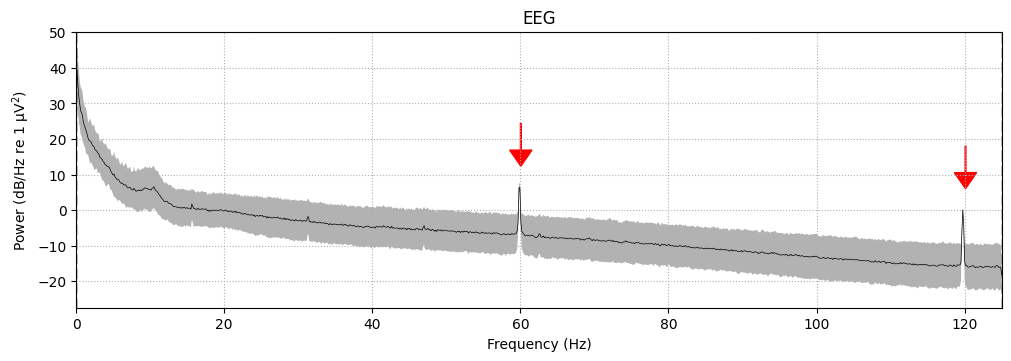

In [64]:
## View Spectrum to Identify Power Line Noise

def add_arrows(axes):
    """Add arrows at 60 Hz and its harmonics without indexing past data range."""
    harmonics = (60, 120, 180, 240)
    for ax in axes:
        # Choose the plotted line with the most points to derive freqs/psd safely
        lines = [ln for ln in ax.lines if hasattr(ln, "get_xdata")]
        if not lines:
            continue
        line = max(lines, key=lambda ln: len(ln.get_xdata()))
        freqs = np.asarray(line.get_xdata())
        psds = np.asarray(line.get_ydata())
        if freqs.size == 0 or psds.size == 0:
            continue

        fmax_plot = float(freqs[-1])
        for freq in harmonics:
            # Skip harmonics outside the plotted frequency range
            if freq > fmax_plot:
                continue
            # Find insertion index and clamp to valid range
            idx = int(np.searchsorted(freqs, freq, side="left"))
            if idx >= freqs.size:
                idx = freqs.size - 1
            if idx < 0:
                idx = 0

            # Robust neighborhood for peak arrow height
            i0 = max(0, idx - 4)
            i1 = min(psds.size, idx + 5)
            if i0 >= i1:
                y = float(psds[idx])
            else:
                y = float(psds[i0:i1].max())

            # Draw a short downward arrow
            ax.arrow(
                x=float(freqs[idx]),
                y=y + 18,
                dx=0,
                dy=-12,
                color="red",
                width=0.1,
                head_width=3,
                length_includes_head=True,
            )

# Plot PSD and annotate
fig = raw.compute_psd(fmax=125).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)
add_arrows(fig.axes[:2])

In [65]:
## Notch filter at 60 Hz
freqs = [60.0, 120.0]
raw_filt.notch_filter(freqs=[60.0, 120.0])

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)



<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>

<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>
Filtered channels: ['FP2', 'Pz', 'Cz', 'PO8', 'PO7', 'T8', 'T7', 'F2']
Sampling rate: 250.0
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


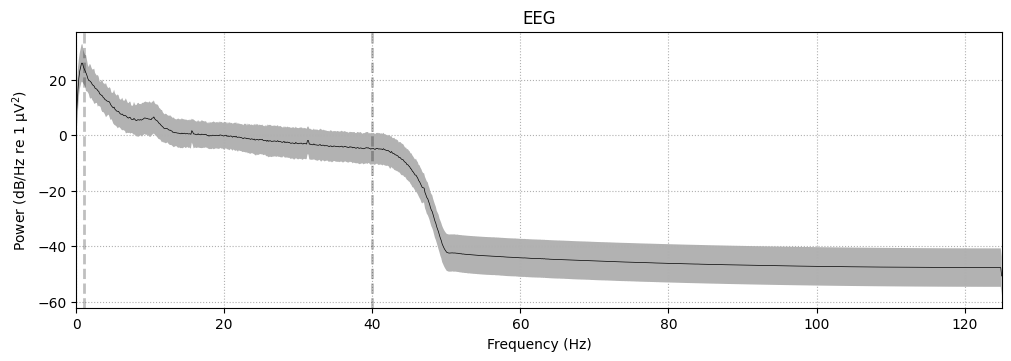

In [66]:
## Display Filtered Data Info and Plot PSD
print(raw_filt)
print("Filtered channels:", raw_filt.ch_names)
print("Sampling rate:", raw_filt.info['sfreq'])
fig = raw_filt.compute_psd(fmax=125).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)

#### 2. *(Optional)* Re-reference with Fp2 to remove eye artifacts

#### 3. Epoch EEG to Gaze-AOI Events

Epoch to events with "AUTO" label set as the 0-point. This event will also then be renamed based on the trial condition. 

Epoch duration: -1000 to 4000 (ms)

In [67]:
## Set up Events for MNE Epoching
# Epoch parameters
epoch_dur = [-1.0, 4.0]  # seconds before and after event (AUTO markers)
baseline = (None, 0)  # baseline correction from start to event onset

# Convert LSL timestamps to sample indices and times relative to EEG start
sfreq = raw_filt.info['sfreq']
eeg_start_lsl = eeg_df['TIMESTAMP'].iloc[0]  # LSL time of first EEG sample

# Add START and BUTTON events as annotations (visible markers, not epochs)
ref_events = events_df[events_df['Type'].isin(['START', 'BUTTON'])].copy()
if len(ref_events) > 0:
    onsets = (ref_events['LSL_Time'] - eeg_start_lsl).values  # seconds relative to raw start
    durations = np.zeros(len(onsets))
    descriptions = ref_events['Type'].values
    
    annotations = mne.Annotations(onset=onsets, duration=durations, description=descriptions)
    raw_filt.set_annotations(annotations)
    print(f"Added {len(annotations)} annotations (START/BUTTON) to continuous EEG data.")

# Build event_id mapping: ONLY condition labels for AUTO events
events_auto = events_df[events_df['Type'] == 'AUTO'].dropna(subset=['LSL_Time', 'CONDITION']).copy()
unique_conditions = sorted(events_auto['CONDITION'].dropna().unique())
event_id = {cond: i + 1 for i, cond in enumerate(unique_conditions)}

print("\nEvent ID mapping:")
print(event_id)

# Compute sample indices for AUTO events
events_auto['sample_idx'] = ((events_auto['LSL_Time'] - eeg_start_lsl) * sfreq).astype(int)

# Assign event IDs based on CONDITION
events_auto['event_id'] = events_auto['CONDITION'].map(event_id)

# Create MNE events array: (n_events, 3) with columns [sample, 0, event_id]
events_mne = events_auto[['sample_idx', 'event_id']].values
events_mne = np.column_stack([events_mne[:, 0], np.zeros(len(events_mne), dtype=int), events_mne[:, 1]])

print(f"\nCreated {len(events_mne)} MNE events.")
print("MNE events array (first 5):")
print(events_mne[:5])

Added 116 annotations (START/BUTTON) to continuous EEG data.

Event ID mapping:
{'HO': 1, 'HT': 2, 'UE': 3, 'UO': 4, 'YT': 5}

Created 16 MNE events.
MNE events array (first 5):
[[ 8854     0     5]
 [ 9125     0     5]
 [37176     0     5]
 [71097     0     2]
 [71738     0     2]]


In [68]:
## Create Epochs at AUTO events only
epochs = mne.Epochs(
    raw_filt,
    events=events_mne,
    event_id=event_id,
    tmin=epoch_dur[0],
    tmax=epoch_dur[1],
    baseline=(None, 0),  # baseline correction from epoch start to time 0
    preload=True,
)

print(epochs)

Not setting metadata
16 matching events found
Setting baseline interval to [-1.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
16 matching events found
Setting baseline interval to [-1.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 16 events and 1251 original time points ...
Using data from preloaded Raw for 16 events and 1251 original time points ...
0 bad epochs dropped
<Epochs | 16 events (all good), -1 – 4 s (baseline -1 – 0 s), ~1.2 MiB, data loaded,
 'HO': 6
 'HT': 5
 'UE': 1
 'UO': 1
 'YT': 3>
0 bad epochs dropped
<Epochs | 16 events (all good), -1 – 4 s (baseline -1 – 0 s), ~1.2 MiB, data loaded,
 'HO': 6
 'HT': 5
 'UE': 1
 'UO': 1
 'YT': 3>


You seem to have overlapping epochs. Some event lines may be duplicated in the plot.


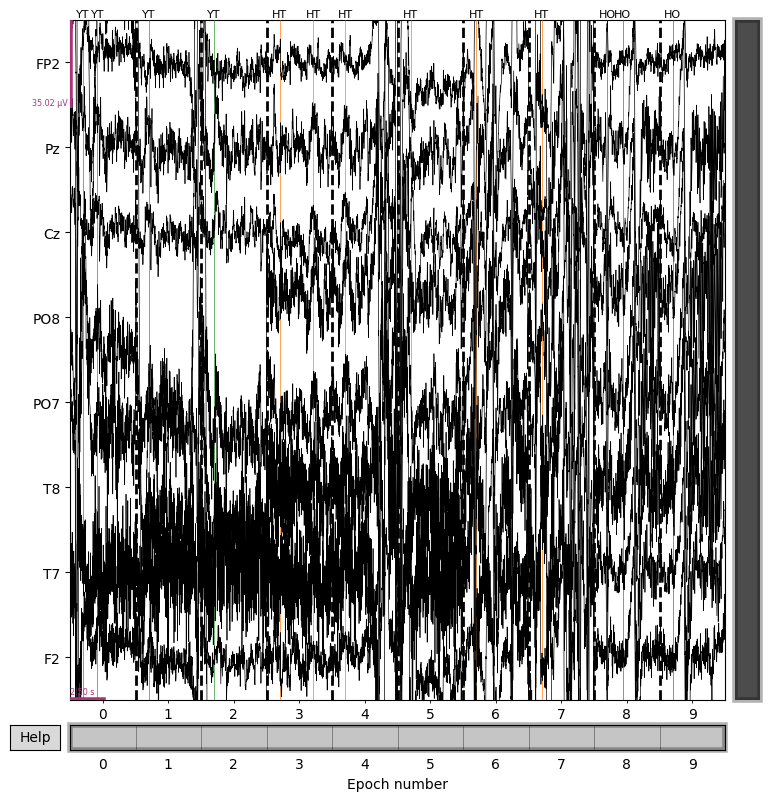

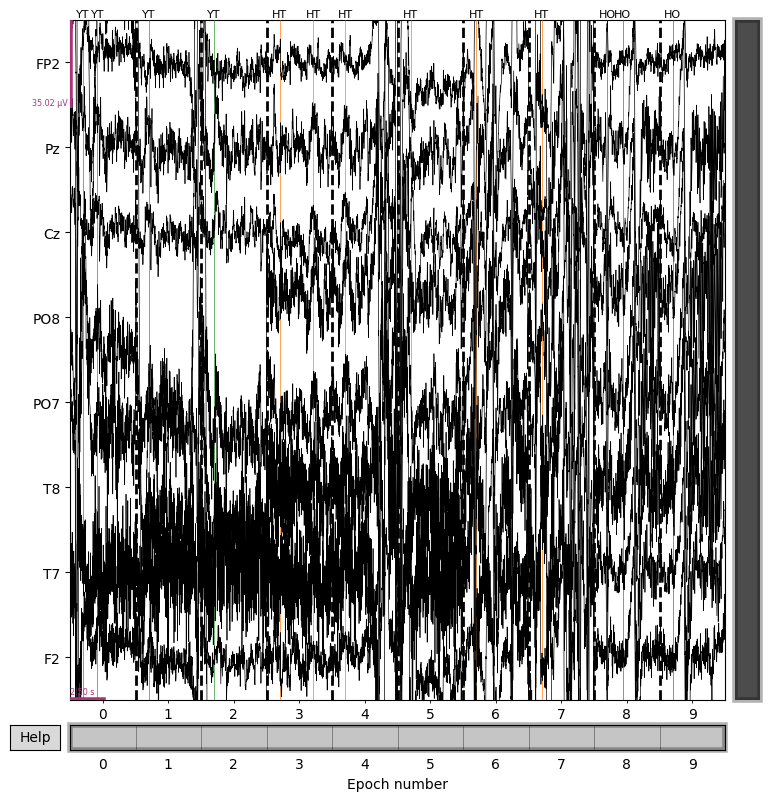

In [85]:
## Plot Epochs
epochs[0:10].plot(n_channels=8, scalings='auto', event_id=True, events=True)

#### 4. Subtract baseline mean from each Epoch  

Set baseline for correction BEFORE movement occurs (e.g. head movement, eye movement, eye-opening)

In [ ]:
## Check all head turn trials to find movement noise duration

In [ ]:
## Check all eye movement trials to find movement noise duration

In [ ]:
## Check all opening eye trials to find movement noise duration

#### 5. *(Optional)* Independent Component Analysis (ICA) to remove artifacts

## ERP Results/Analysis

Visualize and calculate the ERP results across trials.

This should allow for visualization of specific eye movement types and targets, averaging or selecting specific trials as necessary.

We also want to analyze N250 (PO8,PO7,T8,T7,F2) and P300 (Pz,Cz) in particular. The plots will show a shaded region that is considered when averaging to find these components, and the scripts should print out the associated voltage level (Mean +/- SD)